# Personal Viewing Habits Analysis

## Introduction

I used **Exploratory Data Analysis (EDA)** to investigate my personal viewing history and identify patterns and trends in my viewing habits.

The analysis focuses on four key questions:

1. What have I watched?
2. How much have I watched?
3. Has my viewing behaviour changed over time?
4. Has my taste changed over time?

## Data Loading, Understanding, and Preparation

This section loads the viewing-history dataset and performs basic data-quality checks before the EDA. The checks focus on the dataset structure, duplicate records, missing values, and the variables used in later analysis.

In [56]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [57]:
# Load the dataset
pd.set_option('display.max_columns', None)
url = "https://docs.google.com/spreadsheets/d/1vJz34C2fsi-LybkGf_Fc8UFVJJya2vmd6-0izhjX1gE/export?format=csv"
df = pd.read_csv(url)
df.head()

,ID,Titles,Release Year,Watch Year,Genre,Rating,Episodes,Duration (Minutes),Type,Country of Origin
0,1,Bhagg Beanie Bhagg,2020,2020,"Comedy,Romance",3.6,6.0,29,TV Series,India
1,2,Masaba Masaba S1,2020,2020,"Biography,Drama",6.7,13.0,50,TV Series,India
2,3,Mismatched S1,2020,2020,"Drama,Romance",5.8,14.0,30,TV Series,India
3,4,Fabulous Lives Of Bollywood Wives S1,2020,2020,"Documentary,Drama",4.3,8.0,35,TV Series,India
4,5,Fabulous Lives Of Bollywood Wives S1,2022,2022,"Documentary,Drama",4.3,8.0,35,TV Series,India


In [58]:
# Inspect the dataset structure and check for duplicate records
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

# Get a complete list of columns in the dataset
pd.DataFrame({"Columns": df.columns}).style.hide(axis="index")

Rows: 509
Columns: 10
Duplicate rows: 0


Columns
ID
Titles
Release Year
Watch Year
Genre
Rating
Episodes
Duration (Minutes)
Type
Country of Origin


### Data Quality Check

Before analysing the viewing patterns, I check the dataset dimensions, duplicate records, and missing values. This helps identify whether any basic cleaning is required before calculating statistics or creating visualizations.

In [59]:
# Check missing values in each column
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values.to_frame("Missing Values")

,Missing Values
Episodes,315
ID,0
Titles,0
Release Year,0
Watch Year,0
Genre,0
Rating,0
Duration (Minutes),0
Type,0
Country of Origin,0


### Data Preparation

The dataset contains a mixture of categorical and numerical variables. For the analysis, genres are split into individual categories so that multi-genre titles can be represented correctly. Missing episode counts are handled as one episode when estimating total viewing time.

A derived **Total Minutes** field is created as:

**Episodes × Duration (Minutes)**

This provides an estimate of total viewing time for each viewing record and allows yearly viewing time to be compared.

In [60]:
# Prepare the duration measure used for time-based analysis

# Missing episode counts are treated as one episode.
df["Episodes"] = df["Episodes"].fillna(1)

# Estimate total viewing time for each viewing record.
df["Total Minutes"] = df["Episodes"] * df["Duration (Minutes)"]

## Q1. What Have I Watched?

### 1.1 Content Type

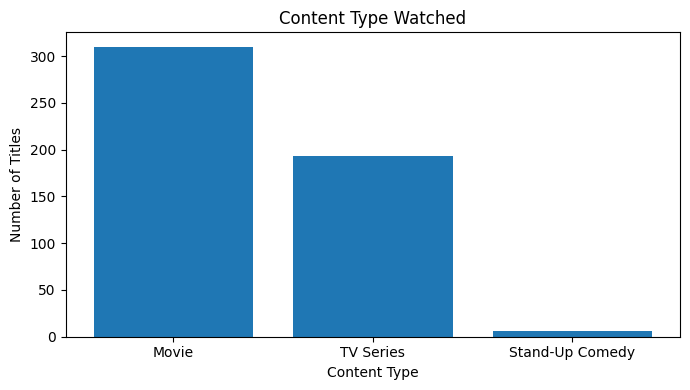

In [61]:
# Calculate the number of titles by content type
type_counts = df["Type"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(type_counts.index, type_counts.values)
plt.title("Content Type Watched")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

> <b>Key Insight:</b> Movies are the most frequently watched content type, followed by TV series, while stand-up comedy represents a much smaller share of the viewing history.

### 1.2 Genres

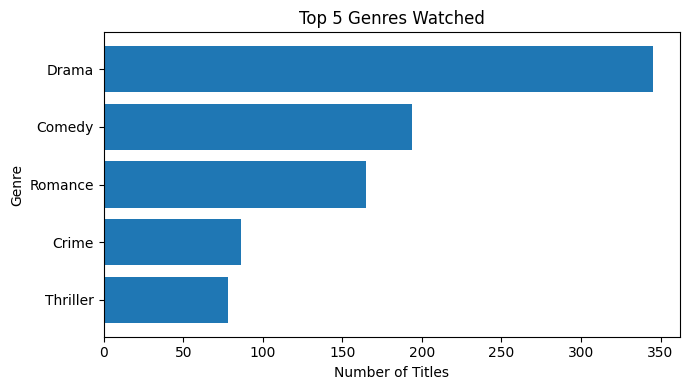

In [62]:
# Split multiple genres into individual genres
genre_df = df.assign(Genre=df["Genre"].str.split(",")).explode("Genre")
genre_df["Genre"] = genre_df["Genre"].str.strip()
genre_counts = genre_df["Genre"].value_counts()
top_genres = genre_counts.head(5)

plt.figure(figsize=(7, 4))
plt.barh(top_genres.index[::-1], top_genres.values[::-1])
plt.title("Top 5 Genres Watched")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

> <b>Key Insight:</b> Drama is the most frequently represented genre, followed by Comedy and Romance. Crime and Thriller also appear among the more common genres, although at lower levels than the leading categories.

### 1.3 Countries of Origin

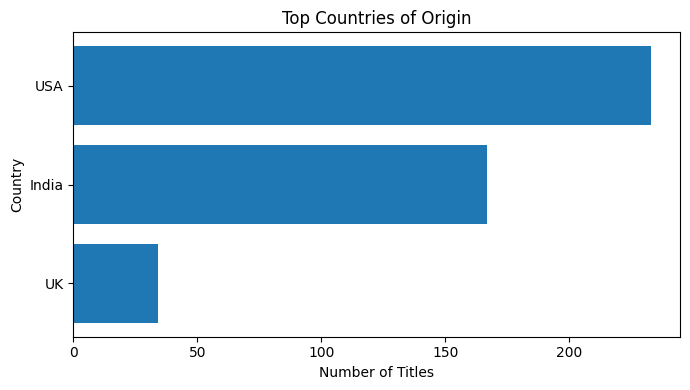

In [63]:
# Calculate the number of titles by country of origin
country_counts = df["Country of Origin"].value_counts()
top_countries = country_counts.head(3)

plt.figure(figsize=(7, 4))
plt.barh(top_countries.index[::-1], top_countries.values[::-1])
plt.title("Top Countries of Origin")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

> <b>Key Insight:</b> The USA is the leading country of origin in the viewing history, followed by India and the UK. This indicates that US-produced content makes up a large part of the viewing history, with Indian content also contributing substantially.

### 1.4 Ratings

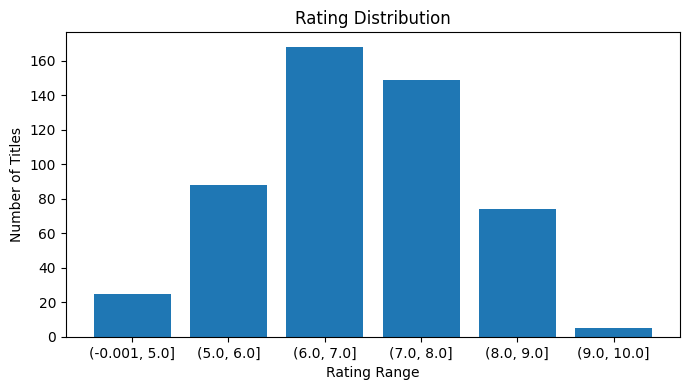

In [64]:
# Group ratings into ranges
rating_bins = pd.cut(df["Rating"], bins=[0, 5, 6, 7, 8, 9, 10], include_lowest=True)
rating_counts = rating_bins.value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Rating Distribution")
plt.xlabel("Rating Range")
plt.ylabel("Number of Titles")
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

> <b>Key Insight:</b> Most watched titles fall within the 6–8 rating range, while titles in the 9–10 range are relatively uncommon.

### 1.5 Release Years

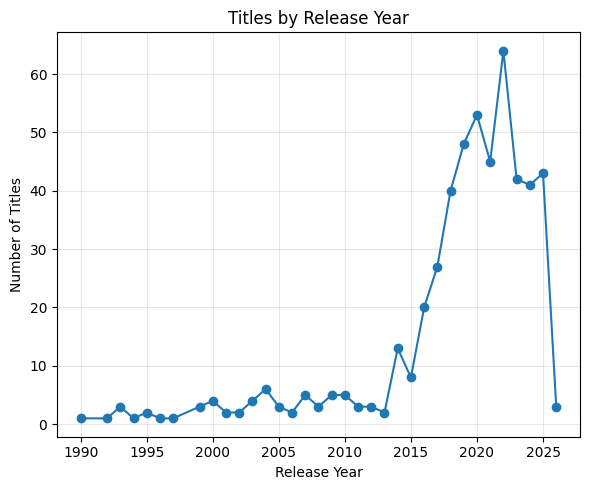

In [65]:
# Calculate the number of titles by release year
release_year_counts = df["Release Year"].value_counts().sort_index()

plt.figure(figsize=(6, 5))
plt.plot(release_year_counts.index, release_year_counts.values, marker="o")
plt.title("Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> <b>Key Insight:</b> The viewing history contains a stronger concentration of more recent releases, with the number of watched titles rising notably after 2015 and peaking in the early 2020s.

## Q2. How Much Have I Watched?

### 2.1 Number of Titles Watched by Year

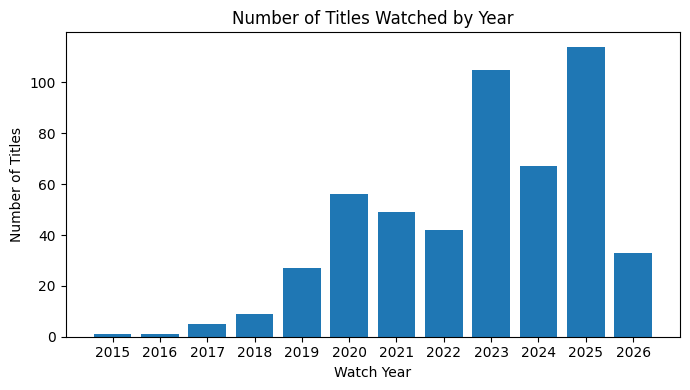

In [66]:
# Calculate the number of titles watched by watch year
titles_by_year = df.groupby("Watch Year").size()

plt.figure(figsize=(7, 4))
plt.bar(titles_by_year.index.astype(str), titles_by_year.values)
plt.title("Number of Titles Watched by Year")
plt.xlabel("Watch Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

> <b>Key Insight:</b> Viewing activity increased substantially over time, reaching its highest level in 2025 with 114 viewing records, followed by 2023 with 105.

### 2.2 Total Viewing Time by Year

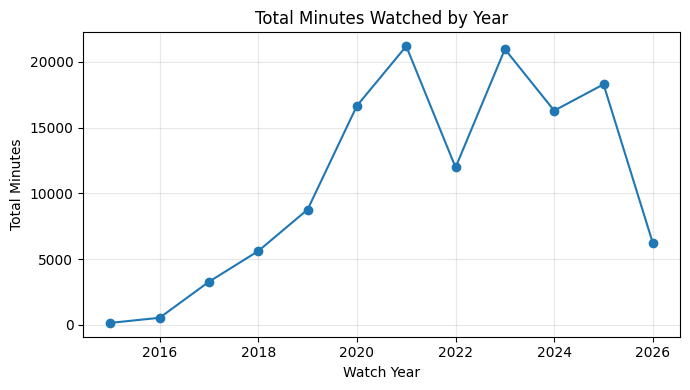

In [67]:
# Aggregate total viewing time by watch year
minutes_by_year = df.groupby("Watch Year")["Total Minutes"].sum()

plt.figure(figsize=(7, 4))
plt.plot(minutes_by_year.index, minutes_by_year.values, marker="o")
plt.title("Total Minutes Watched by Year")
plt.xlabel("Watch Year")
plt.ylabel("Total Minutes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> <b>Key Insight:</b> Estimated total viewing time increased sharply through 2021, reaching 21,185 minutes, and was again high in 2023 at 20,955 minutes before declining in later years.

## Q3. Has My Viewing Behaviour Changed Over Time?

### 3.1 Content Type Mix Over Time

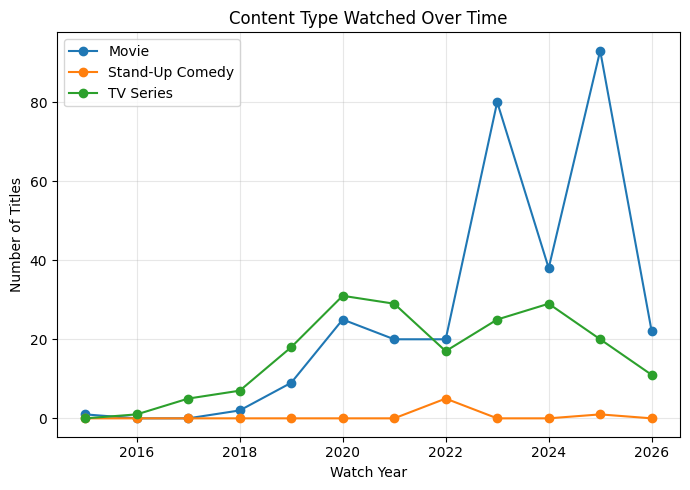

In [68]:
# Compare content-type counts across watch years
type_by_year = pd.crosstab(df["Watch Year"], df["Type"])
type_by_year.plot(marker="o",figsize=(7, 5))

plt.title("Content Type Watched Over Time")
plt.xlabel("Watch Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

> <b>Key Insight:</b> The content mix changed over time. Earlier years were more strongly influenced by TV series, while movies became more prominent in later years; stand-up comedy remained a small component.

### 3.2 Average Duration Over Time

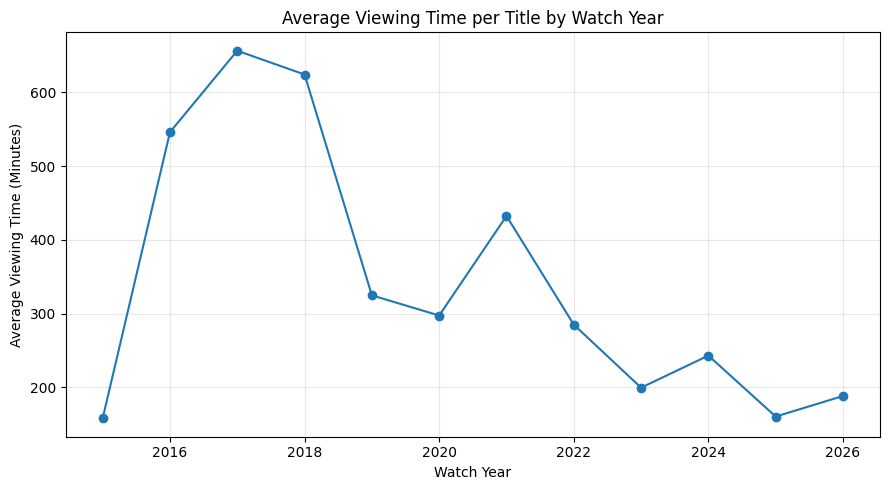

In [69]:
# Calculate average viewing time per title by watch year
average_minutes = df.groupby("Watch Year")["Total Minutes"].mean()

plt.figure(figsize=(9, 5))
plt.plot(average_minutes.index, average_minutes.values, marker="o")
plt.title("Average Viewing Time per Title by Watch Year")
plt.xlabel("Watch Year")
plt.ylabel("Average Viewing Time (Minutes)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> <b>Key Insight:</b> Average estimated viewing duration per record peaked around 2017 and then declined substantially, indicating that later viewing records were generally shorter.

## Q4. Has My Taste Changed Over Time?

### 4.1 Genre Preferences by Watch Year

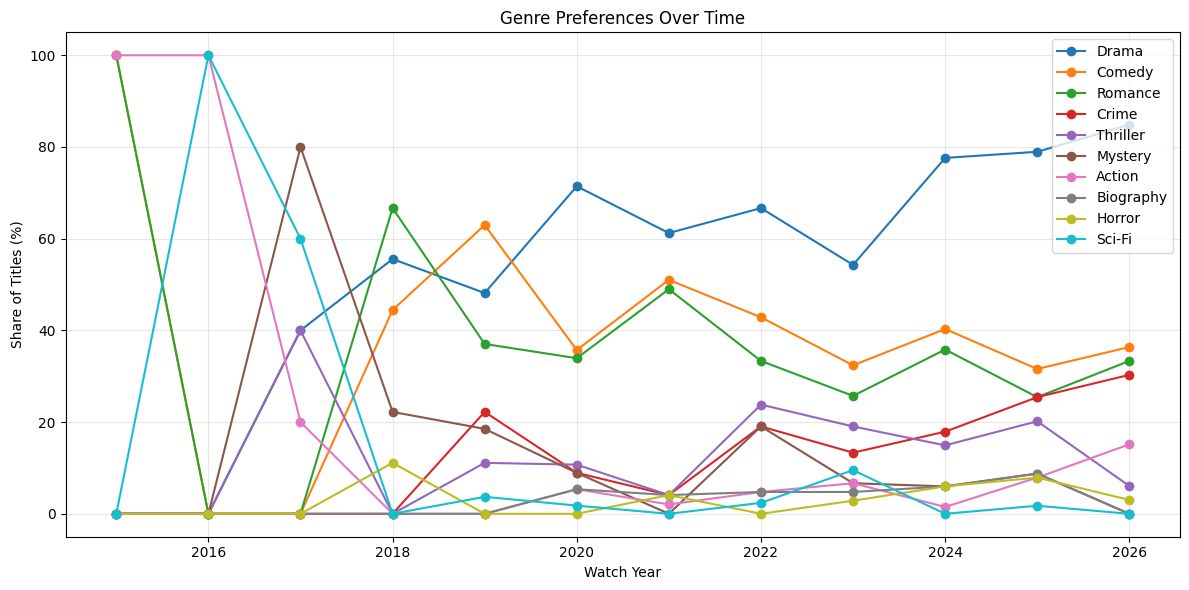

In [70]:
# Compare genre representation across watch years
genre_year = pd.crosstab(genre_df["Watch Year"], genre_df["Genre"])
genre_share_year = genre_year.div(df.groupby("Watch Year").size(), axis=0) * 100

# Select the ten most frequently represented genres
top_10_genres = genre_counts.head(10).index
genre_share_year[top_10_genres].plot(marker="o", figsize=(12, 6))

plt.title("Genre Preferences Over Time")
plt.xlabel("Watch Year")
plt.ylabel("Share of Titles (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

> <b>Key Insight:</b> Genre representation changes over time rather than remaining constant. Drama becomes especially prominent in recent years, while Comedy and Romance remain important but fluctuate across watch years.

<b>Note:</b> Because a title can belong to more than one genre, genre representation percentages may sum to more than 100% within a watch year. These values should therefore be interpreted as the share of watched titles associated with each genre, not as mutually exclusive categories.

## Overall Conclusion

The EDA shows several clear patterns in my personal viewing history:

- **Movies are the most frequently watched content type**, followed by TV series, while stand-up comedy forms a much smaller part of the viewing history.
- **Drama is the leading genre**, with Comedy and Romance also appearing frequently.
- **The USA is the leading country of origin**, followed by India and the UK.
- **Viewing activity increased substantially over time**, with the highest number of viewing records in 2025.
- **Estimated total viewing time was particularly high in 2021 and 2023**, showing that the amount watched varies considerably by year.
- **The content mix changed over time**, with movies becoming more prominent in later years.
- **Average viewing duration generally declined after its earlier peak**, indicating that later viewing records were generally shorter.
- **Genre representation also changed over time**, indicating that my viewing preferences were not completely constant across the years.

Overall, the analysis suggests that my viewing habits have changed in both **volume and composition**. I not only watched more in some later years, but also changed the types and genres of content represented in my viewing history.
